# Task 3: Sentiment and Stock Return Correlation Analysis
This notebook explores the statistical relationship between the emotional tone of news headlines and the daily financial performance of the mentioned companies.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import os
import glob

plt.style.use('ggplot')
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    return analyzer.polarity_scores(str(text))['compound']

# Paths
data_dir = '../data/raw'
stock_files = [f for f in glob.glob(os.path.join(data_dir, '*.csv')) if 'raw_analyst_ratings' not in f]
news_file = os.path.join(data_dir, 'raw_analyst_ratings.csv')

## 1. Data Alignment and Return Calculation
We align the news timestamps with stock trading days and calculate the percentage change in closing prices.

In [2]:
all_returns = []
for file in stock_files:
    ticker = os.path.basename(file).split('.')[0]
    df = pd.read_csv(file)
    date_col = 'Date' if 'Date' in df.columns else 'date'
    df[date_col] = pd.to_datetime(df[date_col], utc=True).dt.date
    df.set_index(date_col, inplace=True)
    df.sort_index(inplace=True)
    
    # Calculate daily returns
    df['Daily_Return'] = df['Close'].pct_change()
    
    temp = df[['Daily_Return']].copy()
    temp['stock'] = ticker
    all_returns.append(temp)

returns_df = pd.concat(all_returns).reset_index()
returns_df.rename(columns={'index': 'date', 'Date': 'date'}, inplace=True)

## 2. Sentiment Quantification
We process the headlines using VADER and aggregate them to a daily average per stock. Crucially, we handle mixed date formats to ensure no data is lost.

In [3]:
news_df = pd.read_csv(news_file, usecols=['headline', 'date', 'stock'])
news_df = news_df[news_df['stock'].isin(returns_df['stock'].unique())].copy()

def parse_date(d):
    try: return pd.to_datetime(d).date()
    except:
        try: return pd.to_datetime(d, utc=True).date()
        except: return None

news_df['date'] = news_df['date'].apply(parse_date)
news_df.dropna(subset=['date'], inplace=True)

# Calculate sentiment
print("Calculating sentiment scores...")
news_df['sentiment'] = news_df['headline'].apply(get_sentiment)

# Daily aggregation
daily_sentiment = news_df.groupby(['date', 'stock'])['sentiment'].mean().reset_index()

Calculating sentiment scores...


## 3. Statistical Correlation Analysis
We perform a Pearson correlation analysis to quantify the strength of the linear relationship between sentiment and returns.

In [4]:
merged = pd.merge(returns_df, daily_sentiment, on=['date', 'stock'], how='inner')

correlation = merged.groupby('stock').apply(lambda x: x['Daily_Return'].corr(x['sentiment']))
print("\nPearson Correlation Coefficients:")
print(correlation)


Pearson Correlation Coefficients:
stock
AAPL    0.123939
AMZN    0.166780
GOOG    0.189528
NVDA    0.214769
dtype: float64


## 4. Advanced Analysis: Sentiment Lag
Does today's news predict *tomorrow's* returns? We shift the sentiment data by one day to investigate predictive capability.

In [5]:
merged_sorted = merged.sort_values(['stock', 'date'])
merged_sorted['Prev_Day_Sentiment'] = merged_sorted.groupby('stock')['sentiment'].shift(1)

lag_correlation = merged_sorted.groupby('stock').apply(lambda x: x['Daily_Return'].corr(x['Prev_Day_Sentiment']))
print("\nLag Correlation (Yesterday's News vs Today's Return):")
print(lag_correlation)


Lag Correlation (Yesterday's News vs Today's Return):
stock
AAPL   -0.207761
AMZN   -0.287680
GOOG   -0.009706
NVDA   -0.024218
dtype: float64


## 5. Visualizing the Relationship
We use scatter plots with regression lines to visualize the distribution of sentiment vs returns.

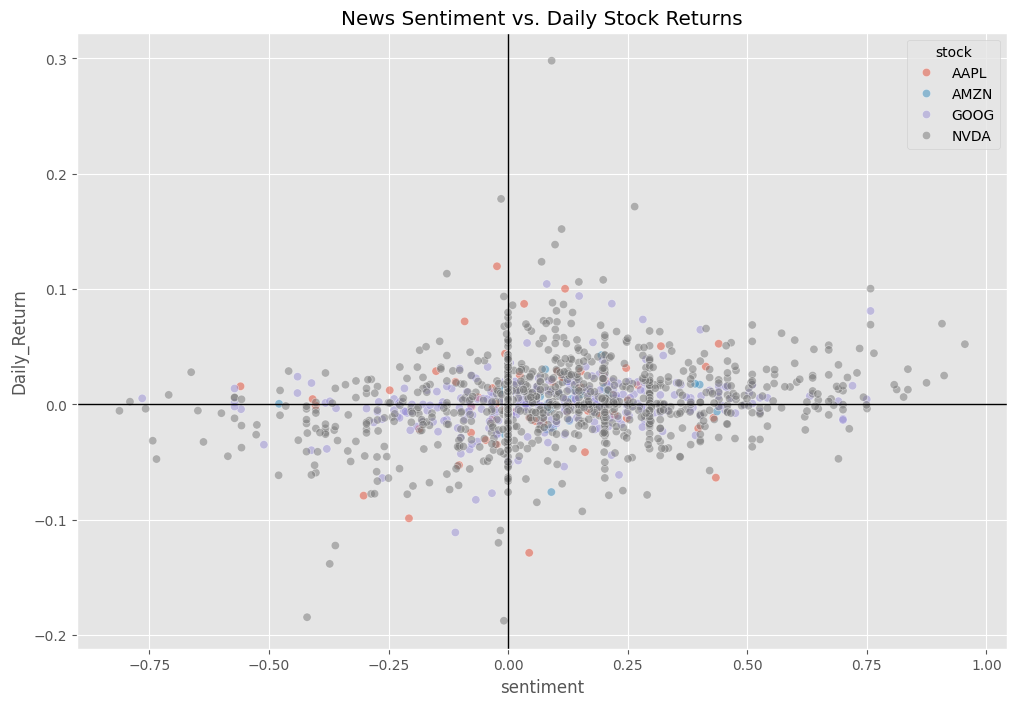

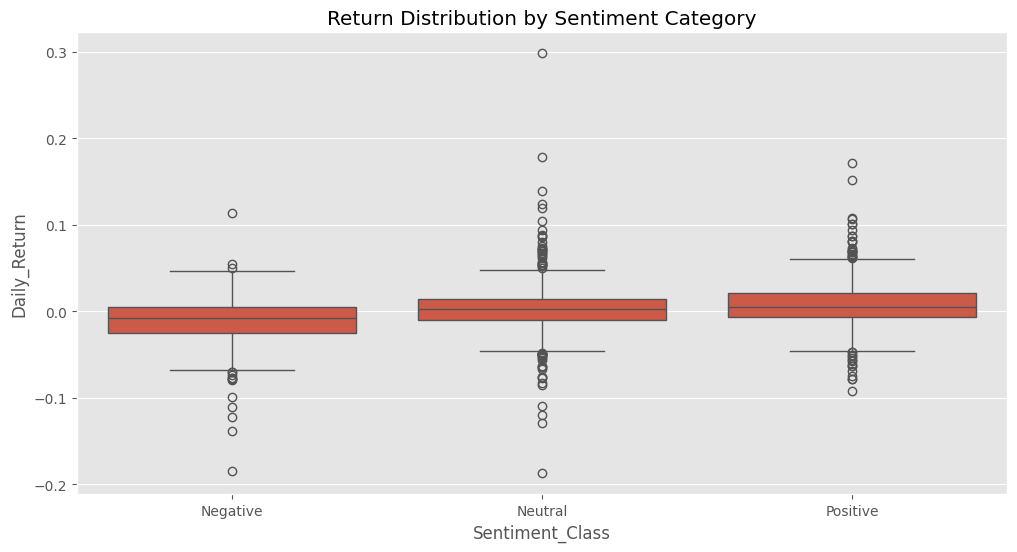

In [6]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=merged, x='sentiment', y='Daily_Return', hue='stock', alpha=0.5)
plt.title('News Sentiment vs. Daily Stock Returns')
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.show()

# Boxplot of returns based on sentiment category
merged['Sentiment_Class'] = pd.cut(merged['sentiment'], bins=[-1, -0.1, 0.1, 1], labels=['Negative', 'Neutral', 'Positive'])
plt.figure(figsize=(12, 6))
sns.boxplot(data=merged, x='Sentiment_Class', y='Daily_Return')
plt.title('Return Distribution by Sentiment Category')
plt.show()